# Clase 12: Visualización de datos con Python

Ahora veremos algunas de las herramientas escenciales para visualizar informacion a partir de estructuras de datos.

Primero debemos instalar las paqueterías de matplotlib y seaborn. Matplotlib nos permite crear gráficos para la visualizacion de los datos mientras que seaborn es una paquetería adicional para darl estilo y formato a las figuras.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
### from google.colab import drive
import os

##Ejercicio 1: Análisis de las carácteristicas y calidad de producción de vino
Ahora empezamos con nuestro ejercio. El primer paso es leer el dataframe con el que vamos a trabajar. Una buena práctica es observar la informacion escencial del dataframe así como la informacion clave.

In [3]:
# Read the dataset
#drive.mount('/content/drive')
#drive_path = "/content/drive/MyDrive/datos/"
#df = pd.read_csv(drive_path+'winequality-red.csv')
df = pd.read_csv('winequality-red.csv')

# Preview the data
df.head()

# Shape
print(f'Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')
print("\n")
# Info
df.info()
print("\n")
# Missing values
df.isnull().sum()
print("\n")
df.describe()

Dataset contains 1599 rows and 12 columns.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB






,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Visualización de informacion

Este dataframe corresponde al análisis de la composicion de diversos vinos de diferentes calidades. Lo que haremo en este ejercicio es tratar de encontrar aquellas características que permitan identificar la calidad de un vino.

Primero hagamos una observación general de la calidad del vino.

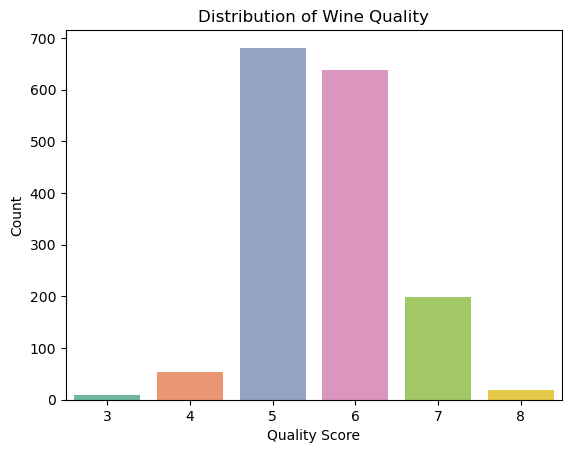

In [4]:
# CREACIÓN DEL GRÁFICO DE BARRAS DE CONTEO
# sns.countplot() crea un gráfico de barras que muestra el conteo de observaciones por categoría
sns.countplot(
    x='quality',           # Especifica la variable del eje X (calidad del vino)
    data=df,               # DataFrame que contiene los datos
    hue='quality',         # Agrupa/colorea las barras por la misma variable 'quality'
    palette='Set2',        # Usa la paleta de colores 'Set2' (esquema de colores predefinido)
    legend=False           # Oculta la leyenda (no es necesaria ya que los colores representan la misma variable)
)

# PERSONALIZACIÓN DEL GRÁFICO

# plt.title() agrega un título descriptivo al gráfico
plt.title('Distribution of Wine Quality')

# plt.xlabel() define la etiqueta del eje X
plt.xlabel('Quality Score')

# plt.ylabel() define la etiqueta del eje Y
plt.ylabel('Count')

# VISUALIZACIÓN
# plt.show() muestra el gráfico en pantalla
plt.show()

### Matriz de correlacion.

La matriz de correlación es una herramienta fundamental en estadística y ciencia de datos que cuantifica las relaciones lineales entre pares de variables en un conjunto de datos.


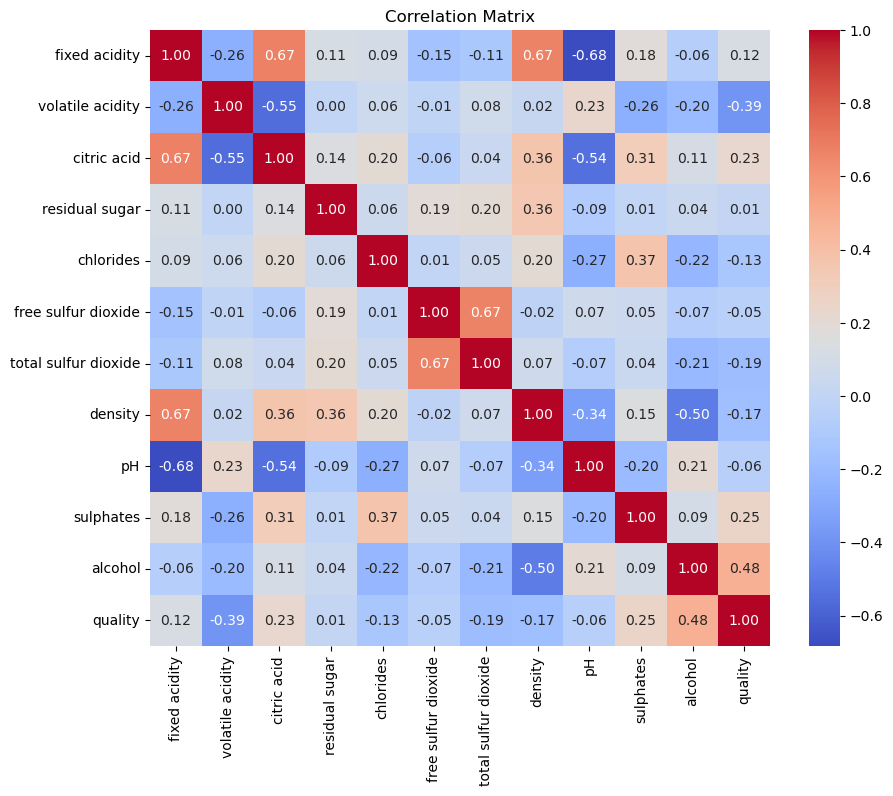

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

In [5]:
# CÁLCULO DE LA MATRIZ DE CORRELACIÓN
# df.corr() calcula los coeficientes de correlación entre todas las variables numéricas del DataFrame
correlation = df.corr()

# CONFIGURACIÓN DE LA FIGURA
# plt.figure() crea una nueva figura y define sus dimensiones
plt.figure(figsize=(10, 8))  # 10 pulgadas de ancho × 8 pulgadas de alto

# CREACIÓN DEL MAPA DE CALOR DE CORRELACIONES
# sns.heatmap() genera una visualización tipo mapa de calor para la matriz de correlación
sns.heatmap(
    correlation,        # Matriz de correlación a visualizar
    annot=True,         # Muestra los valores numéricos de correlación dentro de cada celda
    cmap='coolwarm',    # Usa escala de colores: azul (correlación negativa) a rojo (correlación positiva)
    fmt=".2f"           # Formatea los números a 2 decimales
)

# PERSONALIZACIÓN DEL GRÁFICO
plt.title('Correlation Matrix')  # Título descriptivo del gráfico
plt.show()                       # Muestra el gráfico

# ANÁLISIS DE CORRELACIONES CON LA CALIDAD
# correlation['quality'] selecciona solo la columna de correlaciones con la variable 'quality'
# .sort_values(ascending=False) ordena los valores de mayor a menor correlación
correlation['quality'].sort_values(ascending=False)

### Análisis de la información

Lo que hemos encontrado es información muy interesante.

Primero, la correlacion entre la calidad y el nivel de alcohol es el más grande positivo. Esto significa que el aumento en el nivel de alcohol de un vino está directamente relacionado a la calidad del mismo.

Por otro lado, la correlacion entre la acidéz y la calidad es el mayor negativo. Por lo tanto, la reducción en el nivel de acidéz en un vino está relacionado con una mayor caliad del vino.

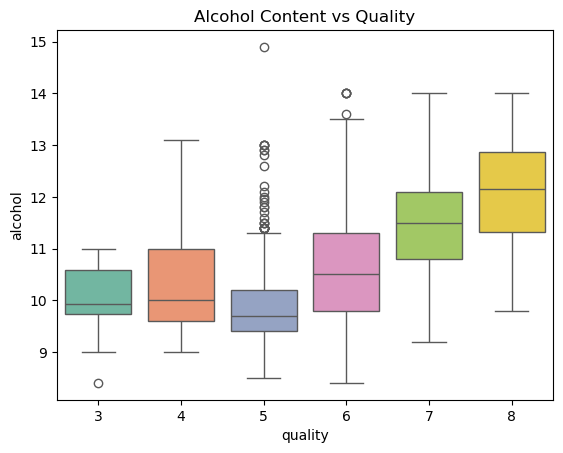

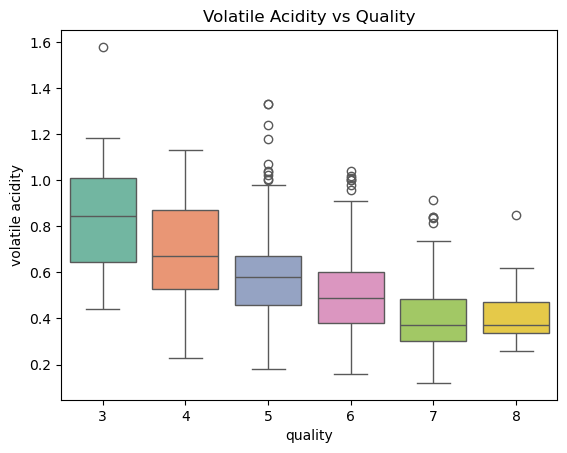

In [6]:
# EJEMPLO 1: RELACIÓN ENTRE ALCOHOL Y CALIDAD
# sns.boxplot() crea un diagrama de caja (boxplot) para visualizar la distribución de una variable numérica por categorías
sns.boxplot(
    x='quality',           # Variable categórica en el eje X (niveles de calidad)
    y='alcohol',           # Variable numérica en el eje Y (contenido de alcohol)
    data=df,               # DataFrame que contiene los datos
    hue='quality',         # Agrupa/colorea por la misma variable de calidad
    palette='Set2',        # Usa la paleta de colores 'Set2'
    legend=False           # Oculta la leyenda (redundante)
)

# Personalización del primer gráfico
plt.title('Alcohol Content vs Quality')  # Título descriptivo
plt.show()                               # Muestra el gráfico

# EJEMPLO 2: RELACIÓN ENTRE ACIDEZ VOLÁTIL Y CALIDAD
sns.boxplot(
    x='quality',               # Variable categórica en el eje X (calidad)
    y='volatile acidity',      # Variable numérica en el eje Y (acidez volátil)
    data=df,                   # DataFrame con los datos
    hue='quality',             # Agrupa por calidad
    palette='Set2',            # Misma paleta de colores para consistencia
    legend=False               # Oculta la leyenda
)

# Personalización del segundo gráfico
plt.title('Volatile Acidity vs Quality')  # Título específico para este análisis
plt.show()                                # Muestra el segundo gráfico

## Ejercicio 2: Análisis del valor de las acciones de Nvidia a través del tiempo


Este notebook demuestra análisis técnico práctico de acciones de NVIDIA utilizando datos históricos reales. Aprenderás a transformar datos financieros en insights accionables mediante diversas técnicas.
### Qué vamos a hacer:

1. Explorar el dataset completo de precios OHLC y volumen
2. Calcular retornos diarios y mensuales
3. Aplicar indicadores técnicos:
    * Medias móviles
    * Volatilidad (True Range)
    * Relación precio-volumen
4. Identificar patrones y tendencias relevantes
5. Visualizar resultados con gráficos profesionales
  
**Herramientas utilizadas:**

* **pandas** para manipulación de datos
* **numpy** para cálculos matemáticos
* **matplotlib** para visualizaciones

In [11]:
# Cargar el dataset
#df = pd.read_csv(drive_path+'Nvidia_stock_data.csv')
df = pd.read_csv('Nvidia_stock_data.csv')
# Mostrar primeras filas
print(df.head())
print("\n")
# Mostrar ultimas filas
print(df.tail())
print("\n")
# Información general
print(df.info())
print("\n")
# Estadísticas descriptivas
print(df['Close'].describe())

         Date     Close      High       Low      Open      Volume
0  1999-01-22  0.037612  0.044775  0.035581  0.040119  2714688000
1  1999-01-25  0.041552  0.042029  0.037612  0.040597   510480000
2  1999-01-26  0.038328  0.042865  0.037731  0.042029   343200000
3  1999-01-27  0.038209  0.039403  0.036298  0.038447   244368000
4  1999-01-28  0.038089  0.038447  0.037850  0.038209   227520000


            Date       Close        High         Low        Open     Volume
6632  2025-06-04  141.919998  142.389999  139.539993  142.190002  167120800
6633  2025-06-05  139.990005  144.000000  138.830002  142.169998  231397900
6634  2025-06-06  141.720001  143.270004  141.509995  142.509995  153986200
6635  2025-06-09  142.630005  145.000000  141.940002  143.190002  185114500
6636  2025-06-10  143.960007  144.289993  141.529999  142.690002  155372400


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6637 entries, 0 to 6636
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
-

### Precio de Cierre - El Indicador Más Importante
**Por qué es crucial:**
1. **Decisiones reales:** Instituciones y fondos usan el cierre para valorar sus activos
2. **Señales confiables:** Las rupturas de soporte/resistencia solo se confirman al cierre
3. **Backtesting:** 95% de estrategias automatizadas se basan en precios de cierre

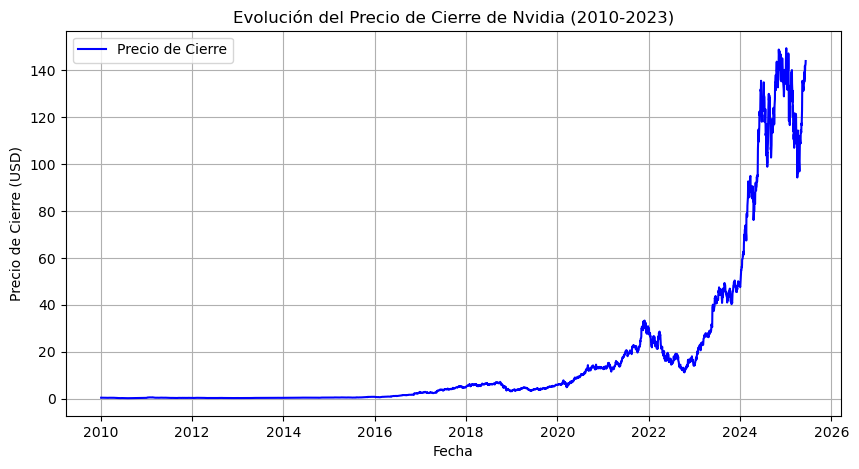

In [12]:
# PREPROCESAMIENTO DE DATOS TEMPORALES

# Convertir la columna 'Date' a formato datetime
# pd.to_datetime() transforma strings o números en objetos de fecha/hora que Python puede entender
df['Date'] = pd.to_datetime(df['Date'])

# FILTRADO DE DATOS POR RANGO TEMPORAL
# Filtramos el DataFrame para conservar solo los datos desde el año 2010 en adelante
df_filtered = df[df['Date'].dt.year >= 2010]
# df['Date'].dt.year extrae el año de cada fecha
# >= 2010 crea una máscara booleana (True/False) para filtrar las filas

# CONFIGURACIÓN DEL LIENZO DEL GRÁFICO
# Creamos una figura con dimensiones específicas para mejor visualización
plt.figure(figsize=(10, 5))  # 10 pulgadas de ancho × 5 pulgadas de alto

# CREACIÓN DEL GRÁFICO DE LÍNEAS TEMPORAL
# plt.plot() genera un gráfico de líneas conectando puntos consecutivos
plt.plot(
    df_filtered['Date'],      # Valores del eje X (fechas)
    df_filtered['Close'],     # Valores del eje Y (precios de cierre)
    label='Precio de Cierre', # Etiqueta para la leyenda
    color='blue'              # Color de la línea
)

# PERSONALIZACIÓN Y ELEMENTOS DEL GRÁFICO
plt.title('Evolución del Precio de Cierre de Nvidia (2010-2023)')  # Título descriptivo
plt.xlabel('Fecha')              # Etiqueta del eje X
plt.ylabel('Precio de Cierre (USD)')  # Etiqueta del eje Y con unidad monetaria
plt.legend()                     # Muestra la leyenda con las etiquetas definidas
plt.grid()                       # Agrega una cuadrícula para facilitar la lectura de valores
plt.show()                       # Renderiza y muestra el gráfico

### Volumen - El Combustible del Mercado
**Por qué importa:**
1. **Confirma tendencias:** Precio + Volumen = Señal confiable
2. **Liquidez real:** Alto volumen permite entrar/salir sin deslizamiento de precios
3. **Participación institucional:** Grandes movimientos requieren alto volumen

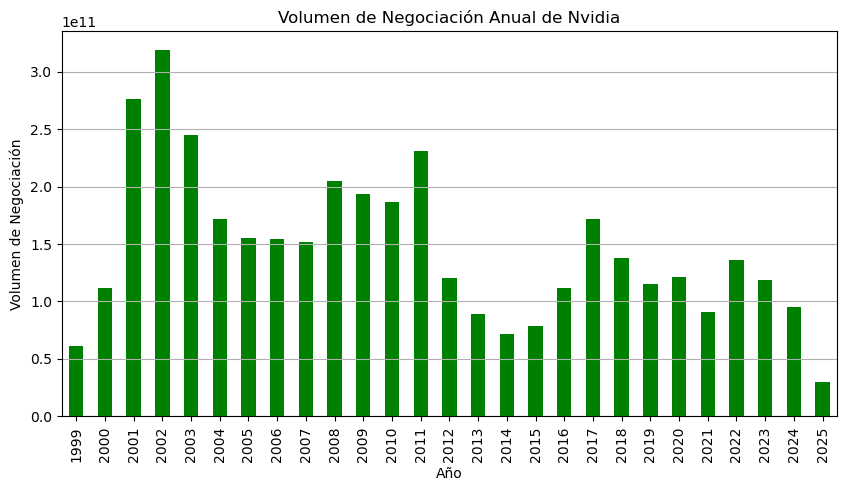

In [13]:
# CREACIÓN DE NUEVA VARIABLE TEMPORAL
# Extraemos el año de la columna de fecha para agrupar los datos por año
df['Year'] = df['Date'].dt.year
# .dt.year accede al componente de año de cada fecha en la columna 'Date'

# CÁLCULO DE AGREGACIÓN ANUAL
# Agrupamos los datos por año y sumamos el volumen de negociación de cada año
annual_volume = df.groupby('Year')['Volume'].sum()
# .groupby('Year') agrupa todas las filas que comparten el mismo año
# ['Volume'].sum() suma todos los valores de volumen dentro de cada grupo anual

# CONFIGURACIÓN DEL LIENZO
plt.figure(figsize=(10, 5))  # Figura de 10×5 pulgadas para buen formato de barras

# CREACIÓN DEL GRÁFICO DE BARRAS
# Usamos el método .plot() de pandas directamente sobre la serie annual_volume
annual_volume.plot(
    kind='bar',   # Tipo de gráfico: barras verticales
    color='green' # Color uniforme para todas las barras
)

# PERSONALIZACIÓN DEL GRÁFICO
plt.title('Volumen de Negociación Anual de Nvidia')  # Título descriptivo
plt.xlabel('Año')              # Etiqueta del eje X (años)
plt.ylabel('Volumen de Negociación')  # Etiqueta del eje Y (unidades de volumen)
plt.grid(axis='y')             # Cuadrícula solo en el eje Y para facilitar lectura vertical
plt.show()                     # Mostrar el gráfico

### Máximos y Mínimos - Los Límites del Mercado
**Por qué es vital:**
1. **Define el rango diario:** Donde compradores y vendedores se enfrentan
2. **Identifica volatilidad:** Rangos amplios = mayor incertidumbre
3. **Soporte y resistencia:** Los extremos revelan niveles psicológicos clave

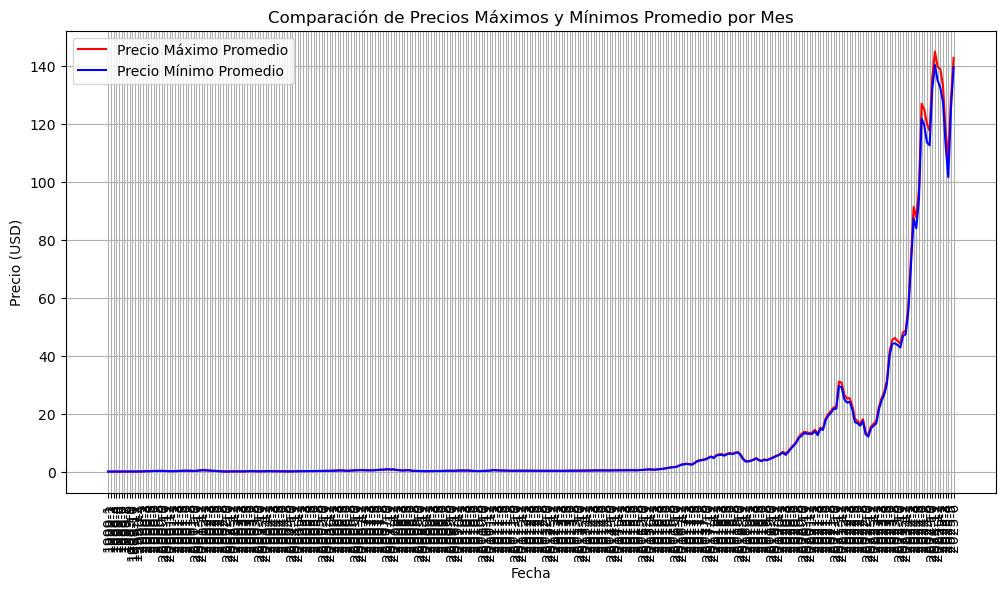

In [14]:
# CREACIÓN DE VARIABLES TEMPORALES
# Extraemos el mes y año de la fecha para agrupar a nivel mensual
df['Month'] = df['Date'].dt.month  # Extrae el número del mes (1-12)
df['Year'] = df['Date'].dt.year    # Extrae el año (ej: 2010, 2011, etc.)

# AGRUPACIÓN Y CÁLCULO DE PROMEDIOS MENSUALES
# Agrupamos por año y mes, luego calculamos el promedio de precios máximos y mínimos
monthly_avg = df.groupby(['Year', 'Month']).agg({
    'High': 'mean',  # Calcula el promedio del precio máximo diario de cada mes
    'Low': 'mean'    # Calcula el promedio del precio mínimo diario de cada mes
}).reset_index()
# .reset_index() convierte 'Year' y 'Month' de índices a columnas normales

# CONFIGURACIÓN DEL LIENZO
plt.figure(figsize=(12, 6))  # Figura ancha para acomodar muchas etiquetas en eje X

# CREACIÓN DE LAS SERIES TEMPORALES
# Primera línea: Precios máximos promedio
plt.plot(
    monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str),  # Crear etiquetas "Año-Mes"
    monthly_avg['High'],              # Valores del eje Y (precios máximos promedio)
    label='Precio Máximo Promedio',   # Etiqueta para la leyenda
    color='red'                       # Color rojo típico para máximos/alzas
)

# Segunda línea: Precios mínimos promedio
plt.plot(
    monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str),  # Mismas etiquetas en eje X
    monthly_avg['Low'],               # Valores del eje Y (precios mínimos promedio)
    label='Precio Mínimo Promedio',   # Etiqueta para la leyenda
    color='blue'                      # Color azul típico para mínimos/bajas
)

# PERSONALIZACIÓN AVANZADA DEL GRÁFICO
plt.title('Comparación de Precios Máximos y Mínimos Promedio por Mes')  # Título descriptivo
plt.xlabel('Fecha')              # Etiqueta del eje X (períodos mensuales)
plt.ylabel('Precio (USD)')       # Etiqueta del eje Y con unidad monetaria
plt.legend()                     # Muestra leyenda con ambas series
plt.xticks(rotation=90)          # Rota las etiquetas del eje X 90° para mejor legibilidad
plt.grid()                       # Agrega cuadrícula para facilitar lectura de valores
plt.show()                       # Renderiza y muestra el gráfico

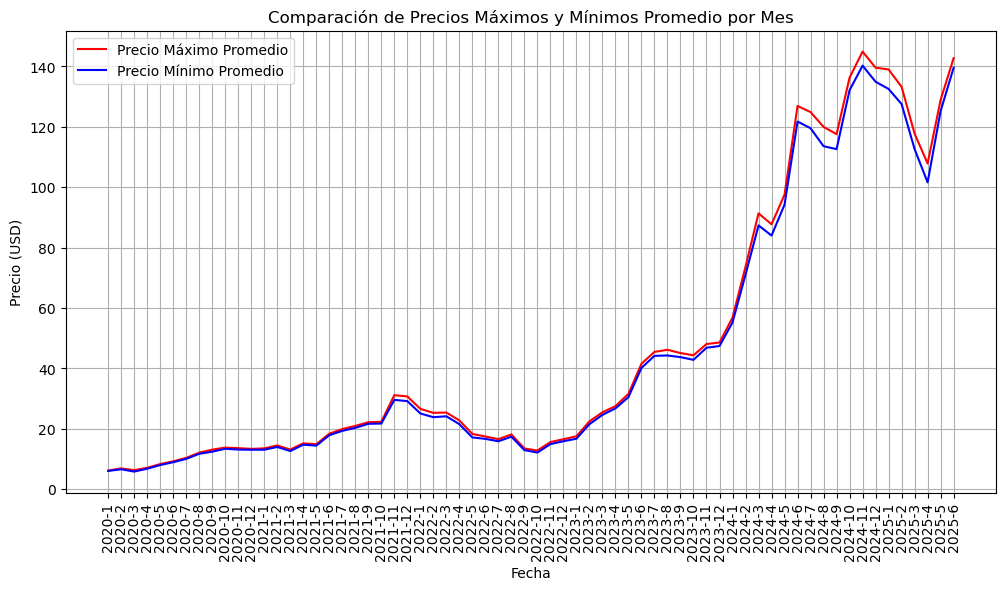

In [15]:
# CREACIÓN DE VARIABLES TEMPORALES
# Extraemos el mes y año de la fecha para agrupar a nivel mensual
df['Month'] = df['Date'].dt.month  # Extrae el número del mes (1-12)
df['Year'] = df['Date'].dt.year    # Extrae el año (ej: 2020, 2021, etc.)

# AGRUPACIÓN Y CÁLCULO DE PROMEDIOS MENSUALES CON FILTRO TEMPORAL
# Filtramos datos desde 2020 y calculamos promedios mensuales
monthly_avg = (df[df['Year'] >= 2020]      # Filtro: solo datos desde el año 2020
               .groupby(['Year', 'Month'])  # Agrupar por año y mes
               .agg({
                   'High': 'mean',  # Promedio del precio máximo diario
                   'Low': 'mean'    # Promedio del precio mínimo diario
               })
               .reset_index())      # Convertir índices a columnas normales

# CONFIGURACIÓN DEL LIENZO
plt.figure(figsize=(12, 6))  # Figura ancha para acomodar etiquetas mensuales

# CREACIÓN DE LAS SERIES TEMPORALES
# Primera línea: Precios máximos promedio
plt.plot(
    monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str),  # Crear etiquetas "Año-Mes"
    monthly_avg['High'],              # Valores del eje Y (precios máximos promedio)
    label='Precio Máximo Promedio',   # Etiqueta para la leyenda
    color='red'                       # Color rojo para máximos
)

# Segunda línea: Precios mínimos promedio
plt.plot(
    monthly_avg['Year'].astype(str) + '-' + monthly_avg['Month'].astype(str),  # Mismas etiquetas en eje X
    monthly_avg['Low'],               # Valores del eje Y (precios mínimos promedio)
    label='Precio Mínimo Promedio',   # Etiqueta para la leyenda
    color='blue'                      # Color azul para mínimos
)

# PERSONALIZACIÓN AVANZADA DEL GRÁFICO
plt.title('Comparación de Precios Máximos y Mínimos Promedio por Mes')  # Título descriptivo
plt.xlabel('Fecha')              # Etiqueta del eje X (períodos mensuales)
plt.ylabel('Precio (USD)')       # Etiqueta del eje Y con unidad monetaria
plt.legend()                     # Muestra leyenda con ambas series
plt.xticks(rotation=90)          # Rota etiquetas del eje X 90° para mejor legibilidad
plt.grid()                       # Agrega cuadrícula para facilitar lectura
plt.show()                       # Renderiza y muestra el gráfico